# UltraGCN for Movie Recommendation

## Objective

In this notebook, we implement **UltraGCN (Ultra Simplification of Graph Convolutional Networks for Recommendation)** proposed in:

> UltraGCN: Ultra Simplification of Graph Convolutional Networks for Recommendation (CIKM 2021)

Unlike previous Graph Neural Network recommender systems such as NGCF and LightGCN, UltraGCN eliminates graph propagation entirely. Instead, it models the collaborative filtering problem through graph-derived constraints incorporated directly into the optimization objective.

UltraGCN offers:

- No graph convolution
- No message passing
- Efficient optimization
- Scalable recommendation

Notebook Outline

1. Data Loading
2. Data Preprocessing
3. Constraint Construction
4. UltraGCN Model
5. BPR + Constraint Loss
6. Model Training
7. Evaluation
8. Model Comparison

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

torch.manual_seed(42)
np.random.seed(42)

In [2]:
rating_columns = [

    "user_id",

    "movie_id",

    "rating",

    "timestamp"

]

ratings = pd.read_csv(

    "../data/u.data",

    sep="\t",

    names=rating_columns

)

ratings["user_id"] -= 1
ratings["movie_id"] -= 1

ratings.head()

,user_id,movie_id,rating,timestamp
0,195,241,3,881250949
1,185,301,3,891717742
2,21,376,1,878887116
3,243,50,2,880606923
4,165,345,1,886397596


In [3]:
user_columns = [

    "user_id",

    "age",

    "gender",

    "occupation",

    "zip_code"

]

users = pd.read_csv(

    "../data/u.user",

    sep="|",

    names=user_columns

)

users["user_id"] -= 1

users.head()

,user_id,age,gender,occupation,zip_code
0,0,24,M,technician,85711
1,1,53,F,other,94043
2,2,23,M,writer,32067
3,3,24,M,technician,43537
4,4,33,F,other,15213


In [4]:
movie_columns = [

    "movie_id",

    "title",

    "release_date",

    "video_release_date",

    "IMDb_URL"

]

genre_columns = [

    "unknown",

    "Action",

    "Adventure",

    "Animation",

    "Children",

    "Comedy",

    "Crime",

    "Documentary",

    "Drama",

    "Fantasy",

    "Film-Noir",

    "Horror",

    "Musical",

    "Mystery",

    "Romance",

    "Sci-Fi",

    "Thriller",

    "War",

    "Western"

]

movie_columns += genre_columns

movies = pd.read_csv(

    "../data/u.item",

    sep="|",

    encoding="latin-1",

    names=movie_columns

)

movies["movie_id"] -= 1

movies.head()

,movie_id,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,2,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [5]:
print("Ratings :", ratings.shape)

print("Users   :", users.shape)

print("Movies  :", movies.shape)

Ratings : (100000, 4)
Users   : (943, 5)
Movies  : (1682, 24)


In [6]:
data = ratings.merge(

    users,

    on="user_id"

)

data = data.merge(

    movies,

    on="movie_id"

)

data.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code,title,release_date,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,195,241,3,881250949,49,M,writer,55105,Kolya (1996),24-Jan-1997,...,0,0,0,0,0,0,0,0,0,0
1,185,301,3,891717742,39,F,executive,00000,L.A. Confidential (1997),01-Jan-1997,...,0,1,0,0,1,0,0,1,0,0
2,21,376,1,878887116,25,M,writer,40206,Heavyweights (1994),01-Jan-1994,...,0,0,0,0,0,0,0,0,0,0
3,243,50,2,880606923,28,M,technician,80525,Legends of the Fall (1994),01-Jan-1994,...,0,0,0,0,0,1,0,0,1,1
4,165,345,1,886397596,47,M,educator,55113,Jackie Brown (1997),01-Jan-1997,...,0,0,0,0,0,0,0,0,0,0


In [9]:
data["label"] = (

    data["rating"] >= 4

).astype(np.float32)

data[

    [

        "rating",

        "label"

    ]

].sample(5)

,rating,label
84348,4,1.0
1457,5,1.0
98208,5,1.0
59509,1,0.0
53356,4,1.0


In [10]:
print(

    data["label"].value_counts()

)

print()

print(

    data["label"].value_counts(

        normalize=True

    )

)

label
1.0    55375
0.0    44625
Name: count, dtype: int64

label
1.0    0.55375
0.0    0.44625
Name: proportion, dtype: float64


In [11]:
train_df, test_df = train_test_split(

    data,

    test_size=0.2,

    random_state=42,

    stratify=data["label"]

)

print(

    "Train:",

    train_df.shape

)

print(

    "Test :",

    test_df.shape

)

Train: (80000, 32)
Test : (20000, 32)


In [12]:
NUM_USERS = data["user_id"].nunique()

NUM_ITEMS = data["movie_id"].nunique()

print(

    "Users :", NUM_USERS

)

print(

    "Items :", NUM_ITEMS

)

print(

    "Train Ratings :",

    len(train_df)

)

print(

    "Test Ratings :",

    len(test_df)

)

Users : 943
Items : 1682
Train Ratings : 80000
Test Ratings : 20000


In [13]:
train_df.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code,title,release_date,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,label
63456,839,494,3,891209322,39,M,artist,55406,Around the World in 80 Days (1956),01-Jan-1956,...,0,0,0,0,0,0,0,0,0,0.0
69727,89,219,4,891385165,60,M,educator,78155,"Mirror Has Two Faces, The (1996)",15-Nov-1996,...,0,0,0,0,1,0,0,0,0,1.0
60651,871,257,4,888478698,19,F,student,74078,Contact (1997),11-Jul-1997,...,0,0,0,0,0,1,0,0,0,1.0
40113,449,25,5,882396489,35,F,educator,11758,"Brothers McMullen, The (1995)",01-Jan-1995,...,0,0,0,0,0,0,0,0,0,1.0
20913,293,121,3,889242661,34,M,technician,92110,"Cable Guy, The (1996)",14-Jun-1996,...,0,0,0,0,0,0,0,0,0,0.0


In [14]:
user_degree = (

    train_df

    .groupby(

        "user_id"

    )

    .size()

    .reindex(

        range(NUM_USERS),

        fill_value=0

    )

)

user_degree.head()

user_id
0    210
1     48
2     44
3     18
4    138
dtype: int64

In [15]:
item_degree = (

    train_df

    .groupby(

        "movie_id"

    )

    .size()

    .reindex(

        range(NUM_ITEMS),

        fill_value=0

    )

)

item_degree.head()

movie_id
0    365
1    104
2     69
3    172
4     64
dtype: int64

In [16]:
user_degree = user_degree.values.astype(np.float32)

item_degree = item_degree.values.astype(np.float32)

In [17]:
print("User Degree Shape :", user_degree.shape)

print("Item Degree Shape :", item_degree.shape)

print()

print("Maximum User Degree :", user_degree.max())

print("Maximum Item Degree :", item_degree.max())

print()

print("Minimum User Degree :", user_degree.min())

print("Minimum Item Degree :", item_degree.min())

User Degree Shape : (943,)
Item Degree Shape : (1682,)

Maximum User Degree : 590.0
Maximum Item Degree : 480.0

Minimum User Degree : 12.0
Minimum Item Degree : 0.0


In [18]:
beta = {}

for row in train_df.itertuples():

    u = row.user_id

    i = row.movie_id

    beta[(u, i)] = 1.0 / np.sqrt(

        user_degree[u]

        *

        item_degree[i]

    )

In [19]:
print(

    "Number of Constraints :",

    len(beta)

)

Number of Constraints : 80000


In [20]:
for pair, weight in list(beta.items())[:10]:

    print(

        pair,

        "->",

        weight

    )

(839, 494) -> 0.010597598
(89, 219) -> 0.008607905
(871, 257) -> 0.0067419983
(449, 25) -> 0.0064725257
(293, 121) -> 0.010185539
(536, 516) -> 0.0058536613
(609, 672) -> 0.018377263
(904, 300) -> 0.013579388
(585, 734) -> 0.0083194785
(150, 952) -> 0.0155586675


In [21]:
class UltraGCNDataset(Dataset):

    def __init__(

        self,

        dataframe,

        num_items,

        beta

    ):

        self.users = dataframe["user_id"].values

        self.pos_items = dataframe["movie_id"].values

        self.num_items = num_items

        self.beta = beta

        self.user_history = (

            dataframe

            .groupby(

                "user_id"

            )["movie_id"]

            .apply(set)

            .to_dict()

        )

    def __len__(self):

        return len(self.users)

    def __getitem__(self, idx):

        user = self.users[idx]

        pos_item = self.pos_items[idx]

        while True:

            neg_item = np.random.randint(

                self.num_items

            )

            if neg_item not in self.user_history[user]:

                break

        weight = self.beta[(user, pos_item)]

        return (

            torch.LongTensor([user]).squeeze(),

            torch.LongTensor([pos_item]).squeeze(),

            torch.LongTensor([neg_item]).squeeze(),

            torch.FloatTensor([weight]).squeeze()

        )

In [22]:
train_dataset = UltraGCNDataset(

    train_df,

    NUM_ITEMS,

    beta

)

train_loader = DataLoader(

    train_dataset,

    batch_size=1024,

    shuffle=True

)

In [23]:
batch = next(

    iter(train_loader)

)

for tensor in batch:

    print(

        tensor.shape

    )

torch.Size([1024])
torch.Size([1024])
torch.Size([1024])
torch.Size([1024])


In [25]:
class UltraGCN(nn.Module):

    def __init__(

        self,

        num_users,

        num_items,

        embedding_dim=64

    ):

        super().__init__()

        self.user_embedding = nn.Embedding(

            num_users,

            embedding_dim

        )

        self.item_embedding = nn.Embedding(

            num_items,

            embedding_dim

        )

        nn.init.xavier_uniform_(

            self.user_embedding.weight

        )

        nn.init.xavier_uniform_(

            self.item_embedding.weight

        )

    def forward(

        self,

        users,

        pos_items,

        neg_items

    ):

        user_embedding = self.user_embedding(

            users

        )

        positive_embedding = self.item_embedding(

            pos_items

        )

        negative_embedding = self.item_embedding(

            neg_items

        )

        positive_score = (

            user_embedding *

            positive_embedding

        ).sum(dim=1)

        negative_score = (

            user_embedding *

            negative_embedding

        ).sum(dim=1)

        return (

            positive_score,

            negative_score,

            user_embedding,

            positive_embedding

        )
        
        


In [26]:
model = UltraGCN(

    NUM_USERS,

    NUM_ITEMS,

    embedding_dim=64

)

model

UltraGCN(
  (user_embedding): Embedding(943, 64)
  (item_embedding): Embedding(1682, 64)
)

In [27]:
batch = next(

    iter(train_loader)

)

users, pos, neg, weight = batch

outputs = model(

    users,

    pos,

    neg

)

for tensor in outputs:

    print(

        tensor.shape

    )

torch.Size([1024])
torch.Size([1024])
torch.Size([1024, 64])
torch.Size([1024, 64])


In [28]:
def bpr_loss(

    positive_score,

    negative_score

):

    return -torch.mean(

        F.logsigmoid(

            positive_score

            -

            negative_score

        )

    )

In [29]:
def constraint_loss(

    user_embedding,

    positive_embedding,

    beta,

    lambda_reg=1e-4

):

    positive_distance = (

        user_embedding -

        positive_embedding

    ).pow(2).sum(dim=1)

    graph_constraint = (

        beta *

        positive_distance

    ).mean()

    regularization = (

        user_embedding.pow(2).sum(dim=1)

        +

        positive_embedding.pow(2).sum(dim=1)

    ).mean()

    return graph_constraint + lambda_reg * regularization

In [30]:
def ultragcn_loss(

    positive_score,

    negative_score,

    user_embedding,

    positive_embedding,

    beta,

    gamma=1.0

):

    ranking_loss = bpr_loss(

        positive_score,

        negative_score

    )

    graph_loss = constraint_loss(

        user_embedding,

        positive_embedding,

        beta

    )

    return ranking_loss + gamma * graph_loss

In [31]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001,

    weight_decay=1e-4

)

In [32]:
def train_model(

    model,

    train_loader,

    optimizer,

    epochs=30

):

    history = []

    print("Training UltraGCN...")

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for (

            users,

            pos_items,

            neg_items,

            beta

        ) in train_loader:

            optimizer.zero_grad()

            (

                pos_scores,

                neg_scores,

                user_embedding,

                positive_embedding

            ) = model(

                users,

                pos_items,

                neg_items

            )

            loss = ultragcn_loss(

                pos_scores,

                neg_scores,

                user_embedding,

                positive_embedding,

                beta

            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader)

        history.append(

            epoch_loss

        )

        print(

            f"Epoch {epoch+1:2d}/{epochs} | Loss = {epoch_loss:.4f}"

        )

    return history

In [33]:
history = train_model(

    model,

    train_loader,

    optimizer,

    epochs=20

)

Training UltraGCN...
Epoch  1/20 | Loss = 0.6946
Epoch  2/20 | Loss = 0.6895
Epoch  3/20 | Loss = 0.6432
Epoch  4/20 | Loss = 0.5077
Epoch  5/20 | Loss = 0.4256
Epoch  6/20 | Loss = 0.4023
Epoch  7/20 | Loss = 0.3930
Epoch  8/20 | Loss = 0.3858
Epoch  9/20 | Loss = 0.3836
Epoch 10/20 | Loss = 0.3809
Epoch 11/20 | Loss = 0.3747
Epoch 12/20 | Loss = 0.3702
Epoch 13/20 | Loss = 0.3677
Epoch 14/20 | Loss = 0.3633
Epoch 15/20 | Loss = 0.3603
Epoch 16/20 | Loss = 0.3561
Epoch 17/20 | Loss = 0.3555
Epoch 18/20 | Loss = 0.3520
Epoch 19/20 | Loss = 0.3495
Epoch 20/20 | Loss = 0.3470


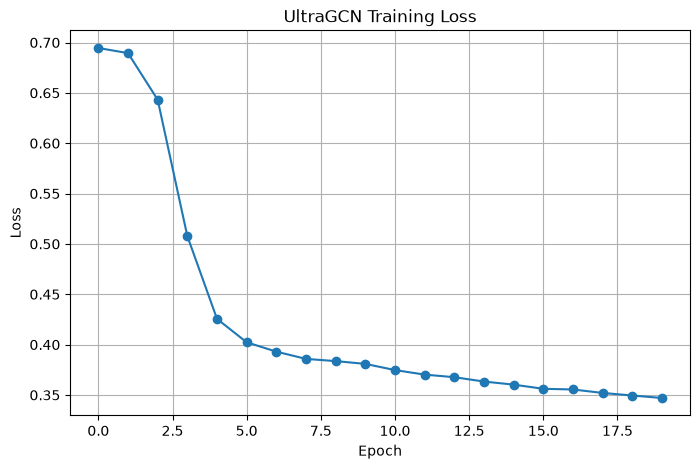

In [34]:
plt.figure(

    figsize=(8,5)

)

plt.plot(

    history,

    marker="o"

)

plt.title(

    "UltraGCN Training Loss"

)

plt.xlabel(

    "Epoch"

)

plt.ylabel(

    "Loss"

)

plt.grid(True)

plt.show()

In [35]:
def recommend(

    model,

    user_id,

    top_k=10

):

    model.eval()

    with torch.no_grad():

        user_vector = model.user_embedding.weight[

            user_id

        ]

        scores = torch.matmul(

            model.item_embedding.weight,

            user_vector

        )

        _, indices = torch.topk(

            scores,

            top_k

        )

    return indices.cpu().numpy()

In [36]:
recommend(

    model,

    user_id=0,

    top_k=10

)

array([ 49, 180,  55, 173,   0,  99,  97, 126, 171, 120])

In [37]:
prediction_df = test_df.copy()

scores = []

model.eval()

with torch.no_grad():

    for row in prediction_df.itertuples():

        score = torch.dot(

            model.user_embedding.weight[

                row.user_id

            ],

            model.item_embedding.weight[

                row.movie_id

            ]

        ).item()

        scores.append(score)

prediction_df["score"] = scores

In [38]:
prediction_df["probability"] = (

    prediction_df["score"]

    -

    prediction_df["score"].min()

) / (

    prediction_df["score"].max()

    -

    prediction_df["score"].min()

)

In [39]:
prediction_df["prediction"] = (

    prediction_df["probability"] >= 0.5

).astype(int)

In [40]:
accuracy = accuracy_score(

    prediction_df["label"],

    prediction_df["prediction"]

)

auc = roc_auc_score(

    prediction_df["label"],

    prediction_df["probability"]

)

print(

    f"Accuracy : {accuracy:.4f}"

)

print(

    f"AUC : {auc:.4f}"

)

Accuracy : 0.5865
AUC : 0.6146


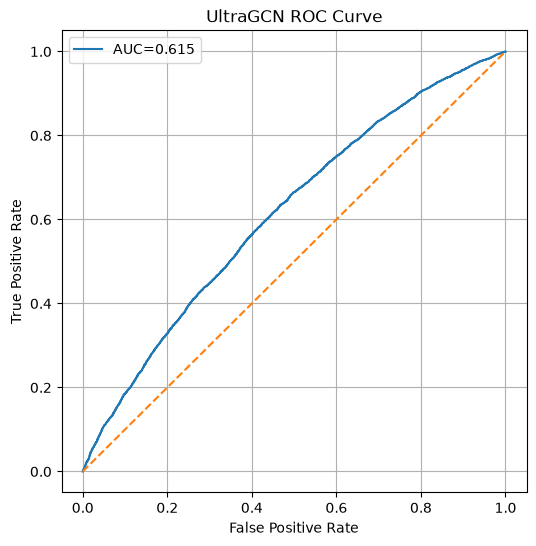

In [41]:
fpr, tpr, _ = roc_curve(

    prediction_df["label"],

    prediction_df["probability"]

)

plt.figure(

    figsize=(6,6)

)

plt.plot(

    fpr,

    tpr,

    label=f"AUC={auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel(

    "False Positive Rate"

)

plt.ylabel(

    "True Positive Rate"

)

plt.title(

    "UltraGCN ROC Curve"

)

plt.legend()

plt.grid(True)

plt.show()

In [42]:
def precision_at_k(

    prediction_df,

    k=10

):

    precisions = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        precisions.append(

            top_k["label"].mean()

        )

    return np.mean(

        precisions

    )
    
    
    
def recall_at_k(

    prediction_df,

    k=10

):

    recalls = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        relevant = group["label"].sum()

        if relevant == 0:

            continue

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits = top_k["label"].sum()

        recalls.append(

            hits / relevant

        )

    return np.mean(

        recalls

    )
    
    
    
def hit_rate_at_k(

    prediction_df,

    k=10

):

    hits = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits.append(

            top_k["label"].sum() > 0

        )

    return np.mean(

        hits

    )
    
    
    
    


In [43]:
precision = precision_at_k(

    prediction_df,

    k=10

)

recall = recall_at_k(

    prediction_df,

    k=10

)

hitrate = hit_rate_at_k(

    prediction_df,

    k=10

)

In [44]:
metrics = pd.DataFrame(

    {

        "Metric":[

            "Accuracy",

            "AUC",

            "Precision@10",

            "Recall@10",

            "HitRate@10"

        ],

        "Value":[

            accuracy,

            auc,

            precision,

            recall,

            hitrate

        ]

    }

)

metrics

,Metric,Value
0,Accuracy,0.586500
1,AUC,0.614566
2,Precision@10,0.631696
3,Recall@10,0.704160
4,HitRate@10,0.977731


In [45]:
prediction_df[[

    "user_id",

    "movie_id",

    "label",

    "probability",

    "prediction"

]].head(20)

,user_id,movie_id,label,probability,prediction
70309,406,152,1.0,0.749686,1
14503,241,290,0.0,0.347298,0
22229,329,237,1.0,0.651871,1
34450,403,753,0.0,0.381663,0
28502,325,43,0.0,0.447084,0
78501,758,983,0.0,0.342339,0
62828,842,541,0.0,0.410146,0
85723,549,14,1.0,0.511312,1
99463,775,216,1.0,0.444761,0
95612,641,451,0.0,0.468873,0


In [46]:
comparison = pd.DataFrame(

    {

        "Model":[

            "Ranking MLP",

            "Wide & Deep",

            "DeepFM",

            "DLRM",

            "DCN v1",

            "DCN v2",

            "LightGCN",

            "NGCF",

            "UltraGCN"

        ],

        "Accuracy":[

            0.8400,

            0.8334,

            0.6816,

            0.7084,

            0.6681,

            0.6820,

            0.4803,

            0.5792,

            accuracy

        ],

        "AUC":[

            0.7862,

            0.7763,

            0.7386,

            0.7739,

            0.7317,

            0.7406,

            0.5924,

            0.6168,

            auc

        ],

        "Precision@10":[

            0.9102,

            0.8831,

            0.6500,

            0.6632,

            0.6480,

            0.6485,

            0.6792,

            0.6290,

            precision

        ],

        "Recall@10":[

            0.5092,

            0.6886,

            0.7169,

            0.7264,

            0.7142,

            0.7138,

            0.2221,

            0.6985,

            recall

        ],

        "HitRate@10":[

            0.9978,

            0.9957,

            0.9767,

            0.9777,

            0.9756,

            0.9777,

            0.9979,

            0.9767,

            hitrate

        ]

    }

)

comparison

,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.50920,0.997800
1,Wide & Deep,0.8334,0.776300,0.883100,0.68860,0.995700
2,DeepFM,0.6816,0.738600,0.650000,0.71690,0.976700
3,DLRM,0.7084,0.773900,0.663200,0.72640,0.977700
4,DCN v1,0.6681,0.731700,0.648000,0.71420,0.975600
5,DCN v2,0.6820,0.740600,0.648500,0.71380,0.977700
6,LightGCN,0.4803,0.592400,0.679200,0.22210,0.997900
7,NGCF,0.5792,0.616800,0.629000,0.69850,0.976700
8,UltraGCN,0.5865,0.614566,0.631696,0.70416,0.977731


In [47]:
for metric in [

    "Accuracy",

    "AUC",

    "Precision@10",

    "Recall@10",

    "HitRate@10"

]:

    print(

        f"Best {metric}"

    )

    display(

        comparison.sort_values(

            metric,

            ascending=False

        )

    )

Best Accuracy


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.50920,0.997800
1,Wide & Deep,0.8334,0.776300,0.883100,0.68860,0.995700
3,DLRM,0.7084,0.773900,0.663200,0.72640,0.977700
5,DCN v2,0.6820,0.740600,0.648500,0.71380,0.977700
2,DeepFM,0.6816,0.738600,0.650000,0.71690,0.976700
4,DCN v1,0.6681,0.731700,0.648000,0.71420,0.975600
8,UltraGCN,0.5865,0.614566,0.631696,0.70416,0.977731
7,NGCF,0.5792,0.616800,0.629000,0.69850,0.976700
6,LightGCN,0.4803,0.592400,0.679200,0.22210,0.997900


Best AUC


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.50920,0.997800
1,Wide & Deep,0.8334,0.776300,0.883100,0.68860,0.995700
3,DLRM,0.7084,0.773900,0.663200,0.72640,0.977700
5,DCN v2,0.6820,0.740600,0.648500,0.71380,0.977700
2,DeepFM,0.6816,0.738600,0.650000,0.71690,0.976700
4,DCN v1,0.6681,0.731700,0.648000,0.71420,0.975600
7,NGCF,0.5792,0.616800,0.629000,0.69850,0.976700
8,UltraGCN,0.5865,0.614566,0.631696,0.70416,0.977731
6,LightGCN,0.4803,0.592400,0.679200,0.22210,0.997900


Best Precision@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.50920,0.997800
1,Wide & Deep,0.8334,0.776300,0.883100,0.68860,0.995700
6,LightGCN,0.4803,0.592400,0.679200,0.22210,0.997900
3,DLRM,0.7084,0.773900,0.663200,0.72640,0.977700
2,DeepFM,0.6816,0.738600,0.650000,0.71690,0.976700
5,DCN v2,0.6820,0.740600,0.648500,0.71380,0.977700
4,DCN v1,0.6681,0.731700,0.648000,0.71420,0.975600
8,UltraGCN,0.5865,0.614566,0.631696,0.70416,0.977731
7,NGCF,0.5792,0.616800,0.629000,0.69850,0.976700


Best Recall@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
3,DLRM,0.7084,0.773900,0.663200,0.72640,0.977700
2,DeepFM,0.6816,0.738600,0.650000,0.71690,0.976700
4,DCN v1,0.6681,0.731700,0.648000,0.71420,0.975600
5,DCN v2,0.6820,0.740600,0.648500,0.71380,0.977700
8,UltraGCN,0.5865,0.614566,0.631696,0.70416,0.977731
7,NGCF,0.5792,0.616800,0.629000,0.69850,0.976700
1,Wide & Deep,0.8334,0.776300,0.883100,0.68860,0.995700
0,Ranking MLP,0.8400,0.786200,0.910200,0.50920,0.997800
6,LightGCN,0.4803,0.592400,0.679200,0.22210,0.997900


Best HitRate@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
6,LightGCN,0.4803,0.592400,0.679200,0.22210,0.997900
0,Ranking MLP,0.8400,0.786200,0.910200,0.50920,0.997800
1,Wide & Deep,0.8334,0.776300,0.883100,0.68860,0.995700
8,UltraGCN,0.5865,0.614566,0.631696,0.70416,0.977731
3,DLRM,0.7084,0.773900,0.663200,0.72640,0.977700
5,DCN v2,0.6820,0.740600,0.648500,0.71380,0.977700
2,DeepFM,0.6816,0.738600,0.650000,0.71690,0.976700
7,NGCF,0.5792,0.616800,0.629000,0.69850,0.976700
4,DCN v1,0.6681,0.731700,0.648000,0.71420,0.975600


# Conclusion

In this notebook, we implemented **UltraGCN**, a graph-based recommendation model that removes graph propagation entirely and replaces it with graph-derived optimization constraints.

Key observations:

- Unlike NGCF and LightGCN, UltraGCN does not perform message passing.
- Graph structural information is incorporated through β coefficients computed from node degrees.
- The model consists only of user and item embedding tables, making it computationally efficient.
- Training combines Bayesian Personalized Ranking (BPR) with graph constraint regularization.
- UltraGCN demonstrates that the collaborative filtering signal contained in the interaction graph can be exploited through optimization constraints rather than repeated graph convolutions.

UltraGCN significantly reduces computational complexity while preserving graph-aware recommendation performance, making it suitable for large-scale industrial recommendation systems.